# Imports and Database Connection

In [44]:
import re
from mongoengine import connect, disconnect
from pycoshark.mongomodels import Project, VCSSystem, Commit, File, FileAction, Hunk, Refactoring, IssueSystem, Issue, IssueComment, MailingList, Message, Event
from pycoshark.utils import create_mongodb_uri_string
import pandas as pd
from collections import defaultdict

# You may have to update this dict to match your DB credentials
credentials = {'db_user': '',
               'db_password': '',
               'db_hostname': 'localhost',
               'db_port': 27017,
               'db_authentication_database': '',
               'db_ssl_enabled': False}

uri = create_mongodb_uri_string(**credentials)

disconnect(alias='default')

connect('smartshark_2_1', host=uri, alias='default')

MongoClient(host=['localhost:27017'], document_class=dict, tz_aware=False, connect=True, read_preference=Primary())

In [45]:
# Print all distinct values for the 'status' field in the Issue collection
distinct_statuses = Issue.objects.distinct('status')
print("\nDistinct statuses in Issue collection:")
for status in distinct_statuses:
    print(status)

distinct_events = Event.objects.distinct('status')
print("\nDistinct statuses in Event collection:")
for event in distinct_events:
    print(event)

# time_spent_events = Event.objects(status='timespent')
# print("\nEvents with status 'time_spent':")
# for event in time_spent_events:
#     print(event)


Distinct statuses in Issue collection:
Blocked
Closed
In Progress
Open
Patch Available
Reopened
Resolved

Distinct statuses in Event collection:
Admin-Comment-Bulk Update Author
Artifact ID
Assignee
Attachment
Attachment License
Browser Version
Bug behavior facts
Bugzilla Id
Bugzilla Import Key
Comment
Complexity
Customer Request Type
Customer(s)
Database
Derby Categories
Derby Info
Description
Docs Text
Epic Child
Epic Link
Epic Name
Epic Status
Estimated Complexity
External issue ID
External issue URL
Fix For
Fix priority
Flagged
Flags
Group ID
Hadoop Flags
INFRA-Members
Issue & fix info
Issue Type
Issue-Comment-Bulk Replace String 
Issue-Comment-Bulk Update Author
JDK Version
Key
Level of effort
O/S Version
Other Info
Parent Issue
Patch
Patch Info
Patch Submitted
Patch attached
Priority
Project
ProjectImport
Rank
Regression
Release Note
RemoteIssueLink
Reproduced In
Request participants
Resolution
Reviewer
Severity
Sprint
Status
Summary
Tags
Target Version/s
Testcase included
Urgen

# Choosing projects

In [46]:
def get_project_statistics_dataframe():
    project_results = {
        p.id: {
            "Project ID": str(p.id),
            "Project Name": p.name,
            "Total Issues": 0, "Open Issues": 0, "Closed Issues": 0, "Resolved Issues": 0,
            "Total Files": 0, "Total File Actions": 0,
            "Linked Issues": 0, "Linked Percentage": 0.0
        }
        for p in Project.objects.only('id', 'name')
    }

    issue_sys_to_proj = {
        sys.id: sys.project_id for sys in IssueSystem.objects.only('id', 'project_id')
    }
    vcs_to_proj = {
        vcs.id: vcs.project_id for vcs in VCSSystem.objects.only('id', 'project_id')
    }
    file_to_vcs = {
        f.id: f.vcs_system_id for f in File.objects.only('id', 'vcs_system_id')
    }
    issue_to_proj = {
        issue.id: issue_sys_to_proj[issue.issue_system_id]
        for issue in Issue.objects.only('id', 'issue_system_id')
        if issue.issue_system_id in issue_sys_to_proj
    }

    # Process all issues
    issue_pipeline = [
        {"$group": {
            "_id": {"system": "$issue_system_id", "status": "$status"},
            "count": {"$sum": 1}
        }}
    ]
    for result in Issue.objects.aggregate(issue_pipeline):
        sys_id = result['_id'].get('system')
        status = result['_id'].get('status', '').lower() if result['_id'].get('status') else ''
        count = result['count']

        if sys_id in issue_sys_to_proj:
            pid = issue_sys_to_proj[sys_id]
            project_results[pid]["Total Issues"] += count
            
            if status == "open":
                project_results[pid]["Open Issues"] += count
            elif status == "closed":
                project_results[pid]["Closed Issues"] += count
            elif status == "resolved":
                project_results[pid]["Resolved Issues"] += count

    # Process all files
    file_pipeline = [{"$group": {"_id": "$vcs_system_id", "count": {"$sum": 1}}}]
    for result in File.objects.aggregate(file_pipeline):
        if result['_id'] in vcs_to_proj:
            project_results[vcs_to_proj[result['_id']]]["Total Files"] += result['count']

    # Process all file actions
    action_pipeline = [{"$group": {"_id": "$file_id", "count": {"$sum": 1}}}]
    for result in FileAction.objects.aggregate(action_pipeline):
        if result['_id'] in file_to_vcs:
            vcs_id = file_to_vcs[result['_id']]
            if vcs_id in vcs_to_proj:
                project_results[vcs_to_proj[vcs_id]]["Total File Actions"] += result['count']

    # Process all issues linked to commits
    unique_linked_issues = set()
    for commit in Commit.objects(linked_issue_ids__not__size=0).only('linked_issue_ids'):
        for issue_id in commit.linked_issue_ids:
            unique_linked_issues.add(issue_id)

    for issue_id in unique_linked_issues:
        if issue_id in issue_to_proj:
            pid = issue_to_proj[issue_id]
            project_results[pid]["Linked Issues"] += 1

    # Calculate linked percentage
    for pid, stats in project_results.items():
        if stats["Total Issues"] > 0:
            stats["Linked Percentage"] = round((stats["Linked Issues"] / stats["Total Issues"]) * 100, 2)
              
    # Create DataFrame table to display results
    data_list = list(project_results.values())
    df = pd.DataFrame(data_list)
    df = df.sort_values(
        by=['Total Issues', 'Linked Percentage', 'Total File Actions', 'Total Files'], 
        ascending=[False, False, False, False]
    )
    
    return df.reset_index(drop=True)

df_projects = get_project_statistics_dataframe()
df_projects

,Project ID,Project Name,Total Issues,Open Issues,Closed Issues,Resolved Issues,Total Files,Total File Actions,Linked Issues,Linked Percentage
0,5e84988880c620a732667310,maven,13238,656,10537,14,9215,59841,3864,29.19
1,5e71c4d43c63727691322420,activemq,7324,716,1681,4798,24709,154962,3622,49.45
2,5bdc03c30da3ef21a62b756c,derby,7027,1213,5716,49,11183,75682,3837,54.60
3,5b0fa95e0da3ef431af80833,kafka,7007,1499,561,4651,5412,52430,3215,45.88
4,5bd022e30da3ef1a10738359,nifi,5813,1586,98,3913,17074,154910,3220,55.39
...,...,...,...,...,...,...,...,...,...,...
72,5bee7a2a0da3ef21a58b337e,commons-imaging,220,50,13,152,1766,10473,69,31.36
73,5bee7a9d0da3ef21a3a094b1,commons-jcs,194,13,163,17,3960,16477,104,53.61
74,5bee79dc0da3ef21a58b337d,commons-digester,194,23,150,16,1923,9730,54,27.84
75,60a24a978d56179891397c71,freemarker,184,49,102,31,7667,57455,44,23.91


Based on these results the following projects have been chosen to perform the experiment on:
- ActiveMQ
- Nifi
- Storm

# Experiment

In [47]:
# Map the projects to their system_ids
target_project_names = ['activemq', 'nifi', 'storm']

vcs_to_proj_name = defaultdict()
proj_to_vcs = defaultdict()

for p in Project.objects(name__in=target_project_names).only('id', 'name'):
    vcs = VCSSystem.objects(project_id=p.id).only('id').first()
    if vcs:
        vcs_to_proj_name[vcs.id] = p.name
        proj_to_vcs[p.name] = vcs.id

target_vcs_ids = list(vcs_to_proj_name.keys())

### Map data
Putting the data of the dataset in data structures such that they can be used for the analysis

In [48]:
vcs_to_commits = defaultdict()
commit_to_issues = defaultdict()
file_to_commit = defaultdict()

project_file_freq = defaultdict() # How many times a file was changed for a project
project_hotspot_issues = defaultdict(set) # List of issues linked to commits that changed a hotspot file for a project
project_normal_issues = defaultdict(set) # List of issues linked to commits that changed a non-hotspot file for a project

project_file_sizes = defaultdict() # Size of each file for a project (using the latest file size available in the database for each file)
project_large_file_issues = defaultdict(set) # List of issues linked to commits that changed a large file for a project
project_normal_file_issues = defaultdict(set) # List of issues linked to commits that changed a

NUMBER_OF_HOTSPOTS = 50
NUMBER_OF_LAREGEST_FILES = 100

for p in Project.objects(name__in=target_project_names).only('id', 'name'):
    vcs_id = proj_to_vcs.get(p.name)
    if vcs_id:
        project_file_freq[vcs_id] = {}
        project_file_sizes[vcs_id] = {}
        # Link all commits related to the vcs
        commits = Commit.objects(vcs_system_id=vcs_id).only('id', 'linked_issue_ids')
        vcs_to_commits[vcs_id] = [c.id for c in commits]
        for c in commits:
            # Link each commit to its linked issues and each issue to its linked commits
            commit_to_issues[c.id] = c.linked_issue_ids

            # Link each commit to its file actions
            file_actions = FileAction.objects(commit_id=c.id).only('id', 'file_id', 'commit_id', 'size_at_commit')

            # Count the file actions for each file for the vcs
            for fa in file_actions:
                file_to_commit.setdefault(fa.file_id, []).append(fa.commit_id)
                project_file_freq[vcs_id][fa.file_id] = project_file_freq[vcs_id].get(fa.file_id, 0) + 1

                project_file_sizes[vcs_id][fa.file_id] = fa.size_at_commit

Retrieve all the issues related to the top NUMBER_OF_HOTSPOTS files that are modified the most in each project

In [49]:
# Calculate and print the top NUMBER_OF_HOTSPOTS hotspot files for each project and relate the linked issues to hotspot and non-hotspot
for vcs_id, freq in project_file_freq.items():
    project_name = vcs_to_proj_name.get(vcs_id, "Unknown Project")
    print(f"\nTop hotspots for project '{project_name}':")

    accumulated_hotspot_issues = set()
    accumulated_normal_issues = set()
    # Sort the files on freq
    sorted_freq_list = sorted(freq.items(), key=lambda x: x[1], reverse=True)

    # Sort the hotspots and add related issues from each hotspot file
    for file_id, count in sorted_freq_list[:NUMBER_OF_HOTSPOTS]:
        file_issues = [
            issue_id 
            for commit_id in file_to_commit.get(file_id, []) 
            for issue_id in commit_to_issues.get(commit_id, [])
        ]
        accumulated_hotspot_issues.update(file_issues)

    # Sort the non-hotspots and add related issues from each non-hotspot file
    for file_id, count in sorted_freq_list[NUMBER_OF_HOTSPOTS:]:
        file_issues = [
            issue_id 
            for commit_id in file_to_commit.get(file_id, []) 
            for issue_id in commit_to_issues.get(commit_id, [])
            if issue_id not in accumulated_hotspot_issues  # Don't count issues linked to hotspot files twice
        ]
        accumulated_normal_issues.update(file_issues)

    project_hotspot_issues[vcs_id] = accumulated_hotspot_issues
    project_normal_issues[vcs_id] = accumulated_normal_issues
    print(f"Total unique linked issues across top {NUMBER_OF_HOTSPOTS} hotspot files for VCS {vcs_id}: {len(project_hotspot_issues[vcs_id])}")
    print(f"Total unique linked issues across top {NUMBER_OF_HOTSPOTS} non-hotspot files for VCS {vcs_id}: {len(project_normal_issues[vcs_id])}")


Top hotspots for project 'activemq':
Total unique linked issues across top 50 hotspot files for VCS 5e71ce99a18d9712488b3a92: 1203
Total unique linked issues across top 50 non-hotspot files for VCS 5e71ce99a18d9712488b3a92: 2417

Top hotspots for project 'storm':
Total unique linked issues across top 50 hotspot files for VCS 5b7ffe9530a71b06bc70c038: 1607
Total unique linked issues across top 50 non-hotspot files for VCS 5b7ffe9530a71b06bc70c038: 149

Top hotspots for project 'nifi':
Total unique linked issues across top 50 hotspot files for VCS 5bd0268235e3ea2b7bbfdbae: 858
Total unique linked issues across top 50 non-hotspot files for VCS 5bd0268235e3ea2b7bbfdbae: 2360


Retrieve all the issues related to the top NUMBER_OF_FILES files that are the largest in each project

In [50]:
# Calculate the largest NUMBER_OF_FILES files for each project and relate the linked issues to those files
for project_id, file_size in project_file_sizes.items():
    project_name = vcs_to_proj_name.get(project_id, "Unknown Project")
    print(f"\nLargest files for project '{project_name}':")

    accumulated_large_file_issues = set()
    accumulated_normal_issues = set()
    # Sort the files on size
    sorted_file_list = sorted(file_size.items(), key=lambda x: x[1], reverse=True)

    # Sort the largest files and add related issues from each large file
    for file_id, size in sorted_file_list[:NUMBER_OF_LAREGEST_FILES]:
        file_issues = [
            issue_id 
            for commit_id in file_to_commit.get(file_id, []) 
            for issue_id in commit_to_issues.get(commit_id, [])
        ]
        accumulated_large_file_issues.update(file_issues)

    # Sort the normal files and add related issues from each normal file
    for file_id, size in sorted_file_list[NUMBER_OF_LAREGEST_FILES:]:
        file_issues = [
            issue_id
            for commit_id in file_to_commit.get(file_id, [])
            for issue_id in commit_to_issues.get(commit_id, [])
        ]
        accumulated_normal_issues.update(file_issues)

    project_large_file_issues[project_id] = accumulated_large_file_issues
    project_normal_file_issues[project_id] = accumulated_normal_issues
    print(f"Total unique linked issues across top {NUMBER_OF_LAREGEST_FILES} largest files for VCS {project_id}: {len(accumulated_large_file_issues)}")
    print(f"Total unique linked issues across top {NUMBER_OF_LAREGEST_FILES} non-largest files for VCS {project_id}: {len(accumulated_normal_issues)}")



Largest files for project 'activemq':
Total unique linked issues across top 100 largest files for VCS 5e71ce99a18d9712488b3a92: 504
Total unique linked issues across top 100 non-largest files for VCS 5e71ce99a18d9712488b3a92: 3554

Largest files for project 'storm':
Total unique linked issues across top 100 largest files for VCS 5b7ffe9530a71b06bc70c038: 530
Total unique linked issues across top 100 non-largest files for VCS 5b7ffe9530a71b06bc70c038: 1755

Largest files for project 'nifi':
Total unique linked issues across top 100 largest files for VCS 5bd0268235e3ea2b7bbfdbae: 212
Total unique linked issues across top 100 non-largest files for VCS 5bd0268235e3ea2b7bbfdbae: 3211


Check properties of events for the selected issues

In [51]:
for vcs_id, project_name in vcs_to_proj_name.items():
    issues_list = list(project_hotspot_issues.get(vcs_id, set()))
    for issue in issues_list:
        print(issue)
        resolution = Event.objects(issue_id=issue, status='resolution')
        for res in resolution:
            print(res)
        status = Event.objects(issue_id=issue, status='status')
        for st in status:
            print(st)
    break

5f0d63605e36a95000e20e73
external_id: 12972759%%1, issue_id: 5f0d63605e36a95000e20e73, created_at: 2006-01-05 11:26:48, status: resolution, author_id: 5f0d6264af02e2d6de86d87a, old_value: None, new_value: Fixed, commit_id: None
external_id: 12972759%%2, issue_id: 5f0d63605e36a95000e20e73, created_at: 2006-01-05 11:26:48, status: status, author_id: 5f0d6264af02e2d6de86d87a, old_value: Open, new_value: Resolved, commit_id: None
5f0d753e5e36a95000e3167c
external_id: 18583221%%0, issue_id: 5f0d753e5e36a95000e3167c, created_at: 2020-02-06 20:44:33.470000, status: resolution, author_id: 5b3b407f30a71b06bc85924a, old_value: None, new_value: Fixed, commit_id: None
external_id: 18583221%%1, issue_id: 5f0d753e5e36a95000e3167c, created_at: 2020-02-06 20:44:33.470000, status: status, author_id: 5b3b407f30a71b06bc85924a, old_value: Open, new_value: Resolved, commit_id: None
5f0d6e685e36a95000e2b386
external_id: 13976553%%1, issue_id: 5f0d6e685e36a95000e2b386, created_at: 2014-02-06 20:34:32.085000,

### Event based cycle time

The selected issues show that there is a timestamp on which most of the issues resolve. Therefore, the cycle time is calculated using the created_at attribute of the issue together with the status event putting the issue on Resolved.

In [59]:
import pandas as pd

def calculate_cycle_time_using_event(unique_issues_set, normal_issues_set, cohort_name):
    cycle_time_results = []
    
    for p in Project.objects(name__in=target_project_names).only('id', 'name'):
        vcs_id = proj_to_vcs.get(p.name)
        if not vcs_id:
            continue
            
        # 1. Isolate the exact issue IDs we need to process
        unique_set = set(unique_issues_set.get(vcs_id, []))
        normal_set = set(normal_issues_set.get(vcs_id, []))
        all_target_issues = list(unique_set | normal_set)
        total_issues = len(all_target_issues)
        
        if total_issues == 0:
            continue
            
        # 2. Fetch the true creation dates from the Issue collection
        issues = Issue.objects(id__in=all_target_issues).only('id', 'created_at')
        issue_created_dict = {i.id: i.created_at for i in issues if i.created_at}
        
        # 3. Push the heavy lifting to the database engine to find the exact resolution timestamps
        # We group by issue_id and take the $max created_at to capture the FINAL time it was closed
        pipeline = [
            {"$match": {
                "issue_id": {"$in": all_target_issues},
                "status": "status",
                "new_value": {"$in": ["Closed", "Resolved", "closed", "resolved"]}
            }},
            {"$group": {
                "_id": "$issue_id",
                "resolved_at": {"$max": "$created_at"}
            }}
        ]
        
        resolution_events = list(Event.objects.aggregate(pipeline))
        issue_resolved_dict = {doc['_id']: doc['resolved_at'] for doc in resolution_events}
        
        # 4. Calculate the durations and track missing data
        data = []
        missing_count = 0
        
        for issue_id in all_target_issues:
            created_at = issue_created_dict.get(issue_id)
            resolved_at = issue_resolved_dict.get(issue_id)
            
            if created_at and resolved_at:
                data.append({
                    'issue_id': issue_id,
                    'created_at': created_at,
                    'resolved_at': resolved_at,
                    'is_unique': issue_id in unique_set
                })
            else:
                missing_count += 1
                
        # 5. Data Quality Reporting
        missing_pct = (missing_count / total_issues) * 100
        print(f"Project '{p.name}': Missing exact resolution data for {missing_count}/{total_issues} issues ({missing_pct:.2f}%).")
        
        if not data:
            continue
            
        # 6. Load into Pandas and execute vectorized mathematical calculations
        df = pd.DataFrame(data)
        df['cycle_time_hours'] = (df['resolved_at'] - df['created_at']).dt.total_seconds() / 3600.0
        
        # Strip negative times (data entry anomalies where resolved_at < created_at)
        df = df[df['cycle_time_hours'] > 0]
        
        is_unique = df['is_unique'] == True
        unique_median = df[is_unique]['cycle_time_hours'].median()
        other_median = df[~is_unique]['cycle_time_hours'].median()
        unique_mean = df[is_unique]['cycle_time_hours'].mean()
        other_mean = df[~is_unique]['cycle_time_hours'].mean()
        
        cycle_time_results.append({
            'Project': p.name,
            f'{cohort_name} Median Cycle (Hours)': unique_median,
            'Other Median Cycle (Hours)': other_median,
            f'{cohort_name} Mean Cycle (Hours)': unique_mean,
            'Other Mean Cycle (Hours)': other_mean,
            f'{cohort_name} Valid Issue Count': is_unique.sum(),
            'Other Valid Issue Count': (~is_unique).sum(),
            'Data Loss (%)': round(missing_pct, 2)
        })

    if cycle_time_results:
        df_cycle_times = pd.DataFrame(cycle_time_results)
        display(df_cycle_times)
        return df_cycle_times
    else:
        print("No valid cycle time data could be extracted.")
        return None

# Execution:
df_event_hotspot = calculate_cycle_time_using_event(project_hotspot_issues, project_normal_issues, "Hotspot")
df_event_large_file = calculate_cycle_time_using_event(project_large_file_issues, project_normal_file_issues, "Large File")

Project 'activemq': Missing exact resolution data for 28/3620 issues (0.77%).
Project 'storm': Missing exact resolution data for 24/1756 issues (1.37%).
Project 'nifi': Missing exact resolution data for 18/3218 issues (0.56%).


,Project,Hotspot Median Cycle (Hours),Other Median Cycle (Hours),Hotspot Mean Cycle (Hours),Other Mean Cycle (Hours),Hotspot Valid Issue Count,Other Valid Issue Count,Data Loss (%)
0,activemq,114.255497,43.358168,2713.934263,2239.449340,1191,2401,0.77
1,storm,303.452066,112.836922,1440.501583,863.980718,1588,144,1.37
2,nifi,419.369946,140.346104,1465.799543,1000.986468,851,2349,0.56


Project 'activemq': Missing exact resolution data for 28/3620 issues (0.77%).
Project 'storm': Missing exact resolution data for 24/1756 issues (1.37%).
Project 'nifi': Missing exact resolution data for 18/3218 issues (0.56%).


,Project,Large File Median Cycle (Hours),Other Median Cycle (Hours),Large File Mean Cycle (Hours),Other Mean Cycle (Hours),Large File Valid Issue Count,Other Valid Issue Count,Data Loss (%)
0,activemq,68.061009,65.096319,2758.239205,2338.050969,502,3090,0.77
1,storm,507.306165,217.233714,1856.566394,1192.946858,521,1211,1.37
2,nifi,451.522480,169.000073,1292.248033,1112.762893,211,2989,0.56


### updated_at based cycle time

Another way to calculate the cycle time is by substracting the latest updated_at from the created_at attribute for the issues. The advantage is that there is not data loss, but the limitation is that after an issue is resolved, the issue can still be updated later creating noise in the data.


In [67]:
def calculate_cycle_times(unique_issues_set, normal_issues_set, cohort_name):
    cycle_time_results = []

    for p in Project.objects(name__in=target_project_names).only('id', 'name'):
        vcs_id = proj_to_vcs.get(p.name)
        if not vcs_id:
            continue
            
        unique_set = set(unique_issues_set.get(vcs_id, []))
        normal_set = set(normal_issues_set.get(vcs_id, []))

        issue_systems = [sys.id for sys in IssueSystem.objects(project_id=p.id).only('id')]
        
        issues = Issue.objects(
            issue_system_id__in=issue_systems,
            status__in=['Closed', 'Resolved']
        ).only('id', 'created_at', 'updated_at')
        
        data = []
        total_missing_timestamps = 0
        for issue in issues:
            if (issue.id in unique_set or issue.id in normal_set):
                if issue.created_at and issue.updated_at:
                    data.append({
                        'issue_id': issue.id,
                        'created_at': issue.created_at,
                        'updated_at': issue.updated_at,
                        'is_unique': issue.id in unique_set
                    })
                else:
                    total_missing_timestamps += 1

        print(f"Project '{p.name}' - Total issues with missing timestamps: {total_missing_timestamps}")

        if not data:
            print(f"No valid closed/resolved issues found for {p.name}")
            continue
            
        df = pd.DataFrame(data)
        
        df['cycle_time_hours'] = (df['updated_at'] - df['created_at']).dt.total_seconds() / 3600.0
        df = df[df['cycle_time_hours'] > 0] 
        is_unique = df['is_unique'] == True
        
        unique_median = df[is_unique]['cycle_time_hours'].median()
        other_median = df[~is_unique]['cycle_time_hours'].median()
        unique_mean = df[is_unique]['cycle_time_hours'].mean()
        other_mean = df[~is_unique]['cycle_time_hours'].mean()
        
        cycle_time_results.append({
            'Project': p.name,
            f'{cohort_name} Median Cycle (Hours)': unique_median,
            'Other Median Cycle (Hours)': other_median,
            f'{cohort_name} Mean Cycle (Hours)': unique_mean,
            'Other Mean Cycle (Hours)': other_mean,
            f'{cohort_name} Issue Count': is_unique.sum(),
            'Other Issue Count': (~is_unique).sum()
        })

    df_cycle_times = pd.DataFrame(cycle_time_results)
    display(df_cycle_times)
    return df_cycle_times

df_naive_hotspot = calculate_cycle_times(project_hotspot_issues, project_normal_issues, "Hotspot")
df_naive_large_file = calculate_cycle_times(project_large_file_issues, project_normal_file_issues, "Large File")

Project 'activemq' - Total issues with missing timestamps: 0
Project 'storm' - Total issues with missing timestamps: 0
Project 'nifi' - Total issues with missing timestamps: 0


,Project,Hotspot Median Cycle (Hours),Other Median Cycle (Hours),Hotspot Mean Cycle (Hours),Other Mean Cycle (Hours),Hotspot Issue Count,Other Issue Count
0,activemq,617.900505,348.848090,5479.880025,4660.719272,1185,2395
1,storm,1127.521966,143.013666,3685.111144,1310.489377,1584,143
2,nifi,721.534589,249.332962,2192.313637,1352.415227,849,2343


Project 'activemq' - Total issues with missing timestamps: 0
Project 'storm' - Total issues with missing timestamps: 0
Project 'nifi' - Total issues with missing timestamps: 0


,Project,Large File Median Cycle (Hours),Other Median Cycle (Hours),Large File Mean Cycle (Hours),Other Mean Cycle (Hours),Large File Issue Count,Other Issue Count
0,activemq,1100.131113,374.251469,6987.960313,4601.184232,496,3084
1,storm,1039.605365,844.396939,3475.850413,3493.900346,518,1209
2,nifi,704.130484,331.568124,1786.040629,1561.004233,210,2982


### Visualization

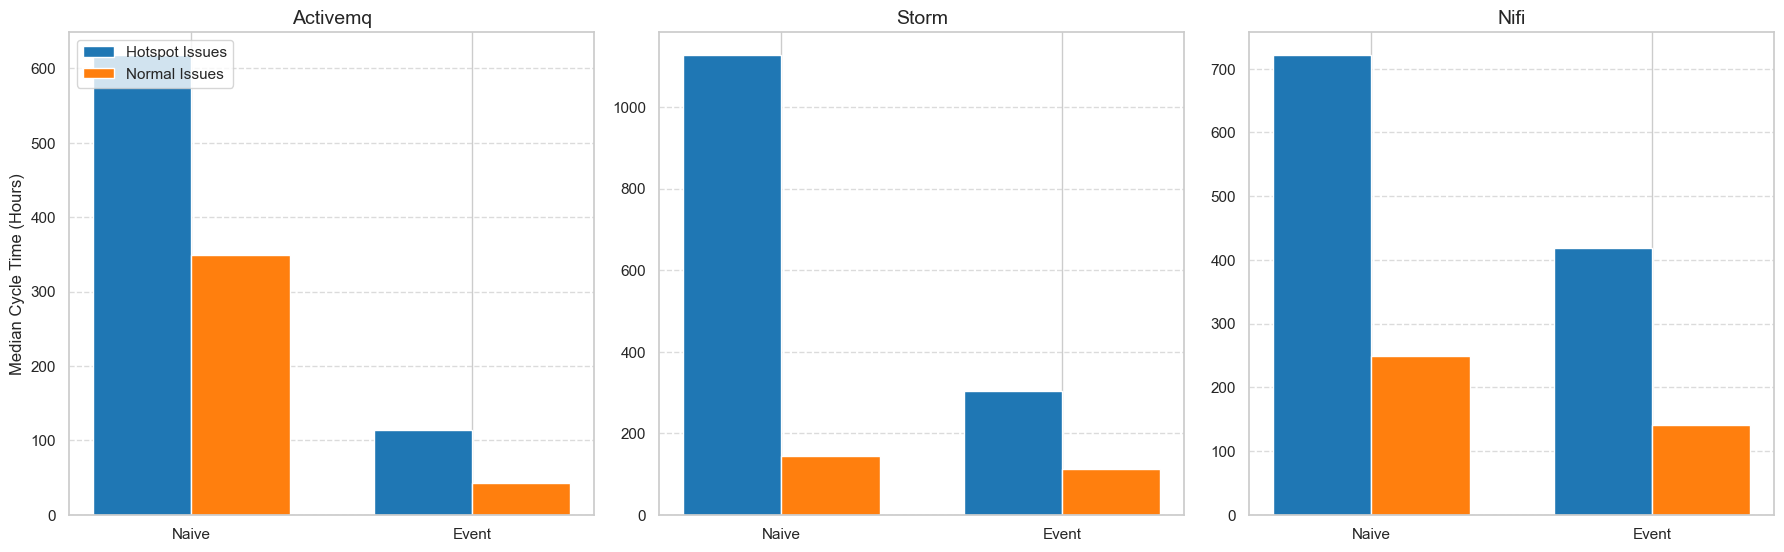

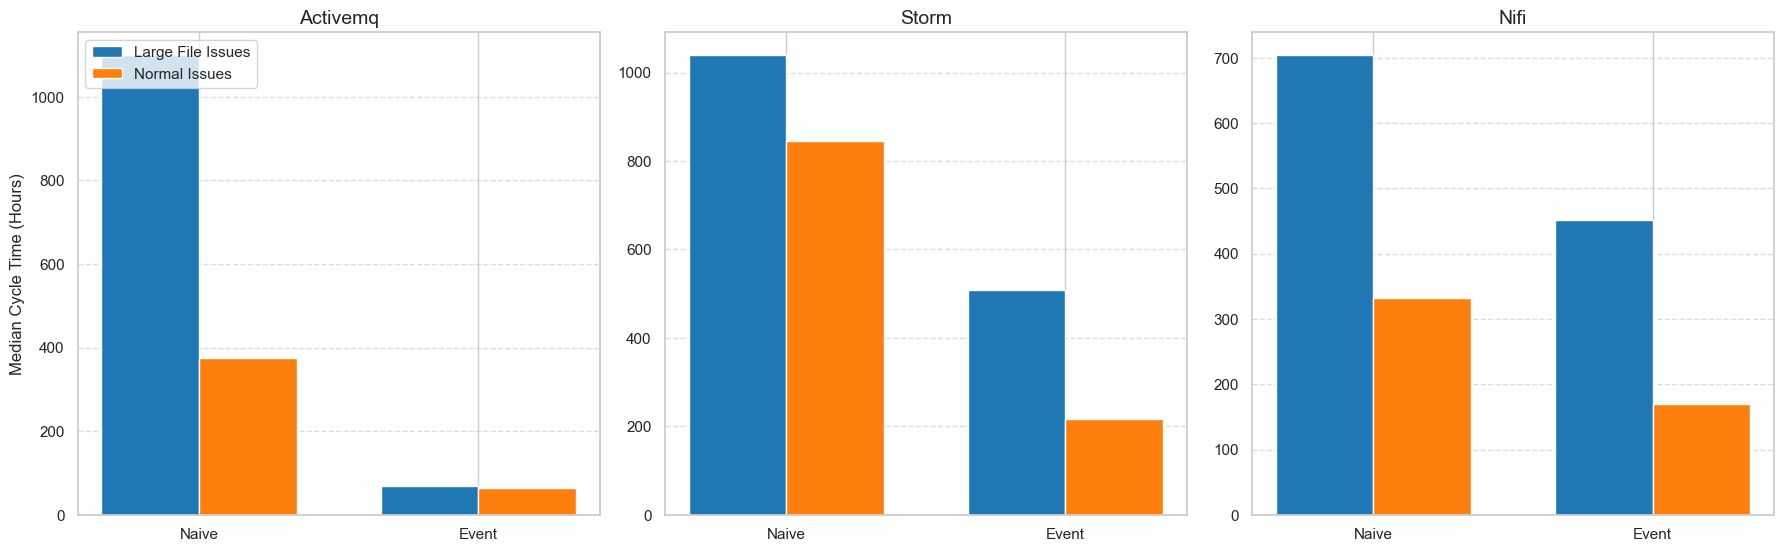

In [78]:
import matplotlib.pyplot as plt
import numpy as np

def plot_combined_project_comparisons(df_naive, df_event, cohort_name):
    """
    Creates a single figure with subplots for each project, 
    comparing Naive vs. Event-based median cycle times side-by-side.
    """
    projects = df_naive['Project'].tolist()
    num_projects = len(projects)
    
    # Create a 1 x num_projects grid of subplots. 
    # sharey=False allows each project to scale to its own data.
    fig, axes = plt.subplots(1, num_projects, figsize=(6 * num_projects, 6), sharey=False)
    
    # Handle edge case where there is only one project
    if num_projects == 1:
        axes = [axes]
        
    labels = ['Naive', 'Event']
    width = 0.35
    x = np.arange(len(labels))
    
    for i, project in enumerate(projects):
        ax = axes[i]
        
        # Extract data for the specific project
        naive_row = df_naive[df_naive['Project'] == project].iloc[0]
        event_row = df_event[df_event['Project'] == project].iloc[0]
        
        naive_cohort = naive_row[f'{cohort_name} Median Cycle (Hours)']
        naive_normal = naive_row['Other Median Cycle (Hours)']
        
        event_cohort = event_row[f'{cohort_name} Median Cycle (Hours)']
        event_normal = event_row['Other Median Cycle (Hours)']
        
        cohort_values = [naive_cohort, event_cohort]
        normal_values = [naive_normal, event_normal]
        
        # Plot bars
        ax.bar(x - width/2, cohort_values, width, label=f'{cohort_name} Issues', color='#1f77b4')
        ax.bar(x + width/2, normal_values, width, label='Normal Issues', color='#ff7f0e')
        
        # Formatting
        ax.set_title(project.capitalize(), fontsize=14)
        ax.set_xticks(x)
        ax.set_xticklabels(labels)
        ax.grid(axis='y', linestyle='--', alpha=0.7)
        
        # Only add y-label and legend to the leftmost subplot to reduce clutter
        if i == 0:
            ax.set_ylabel('Median Cycle Time (Hours)', fontsize=12)
            ax.legend(loc='upper left')

    fig.tight_layout()
    # Shift plots down slightly to make room for the main title
    fig.subplots_adjust(top=0.88) 
    plt.show()

# Generate the combined plots
plot_combined_project_comparisons(df_naive_hotspot, df_event_hotspot, "Hotspot")
plot_combined_project_comparisons(df_naive_large_file, df_event_large_file, "Large File")